## 설치

현재 main 기준 설치 예시입니다.

```bash
uv add git+https://github.com/CGINSIDE-ROOKIES/document-processor
# 또는 로컬 체크아웃에서:
uv pip install -e .
```

In [1]:
from document_processor import DocIR
from pprint import pprint

pprint(DocIR.model_fields)

{'assets': FieldInfo(annotation=dict[str, ImageAsset], required=False, default_factory=dict),
 'doc_id': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'identity_version': FieldInfo(annotation=int, required=False, default=1),
 'meta': FieldInfo(annotation=Union[TypeVar, NoneType], required=False, default=None),
 'pages': FieldInfo(annotation=list[PageInfo], required=False, default_factory=list),
 'paragraphs': FieldInfo(annotation=list[ParagraphIR], required=False, default_factory=list),
 'source_doc_type': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'source_path': FieldInfo(annotation=Union[str, NoneType], required=False, default=None)}


- `identity_version`: 현 미사용 (versioning이나 스키마 버전용)
- `meta`: 필요한 메타데이터 있을 경우 여기다 원하는 데이터 추가 가능 (DataFrame 상속 obj)

In [2]:
from pathlib import Path

DOC_DIR = Path("doc_samples/new_test/")
if not DOC_DIR.exists():
    DOC_DIR = Path("tests/doc_samples/new_test/")

# 예시
FP = DOC_DIR / "style_test_sample.docx"
# FP = DOC_DIR / "style_test_sample.docx"

doc = DocIR.from_file(FP)


In [3]:
doc.source_doc_type, doc.source_path, doc.doc_id

('docx', 'doc_samples/new_test/style_test_sample.docx', 'style_test_sample')

각 페이지 정보

In [4]:
[pprint(page) for page in doc.pages]
print(len(doc.pages))

PageInfo(page_number=1, width_pt=612.0, height_pt=792.0, margin_left_pt=90.0, margin_right_pt=90.0, margin_top_pt=72.0, margin_bottom_pt=72.0)
PageInfo(page_number=2, width_pt=612.0, height_pt=792.0, margin_left_pt=90.0, margin_right_pt=90.0, margin_top_pt=72.0, margin_bottom_pt=72.0)
PageInfo(page_number=3, width_pt=612.0, height_pt=792.0, margin_left_pt=90.0, margin_right_pt=90.0, margin_top_pt=72.0, margin_bottom_pt=72.0)
3


In [5]:
len(doc.paragraphs)

34

In [6]:
tables = [table for para in doc.paragraphs for table in para.tables]


In [7]:
from document_processor import ImageIR, RunIR, TableIR

texts = []
for para in doc.paragraphs:
    for content in para.content:
        if isinstance(content, RunIR):
            texts.append((content.node_id, content.text))
        elif isinstance(content, ImageIR):
            texts.append((content.node_id, content.alt_text))
        elif isinstance(content, TableIR):
            texts.append((content.node_id, content.markdown))

for t in texts[:20]:
    print(f'{t[0]}: {t[1] if '\n' not in t[1] else '\n' + t[1]}')

r_f017369d1a2e2a89: 표준근로계약서
r_3f1ff7241702452b:  (
r_b50e4515a09b03c5: 샘플
r_5e770a9defab6b1c: )
r_70a2dd7d5d150def: 
r_b72701cc86502509: 제
r_c44a1729ccfb9597: 1
r_65a8209684b0ea88: 조
r_f3f292e0532c2ffb:  
r_5761ac9a3aa372d4: (
r_34a0132dbd492db3: 계약의
r_b40457dc243ecb96:  
r_d48792d721e0fe77: 목적
r_65845849f817f48e: )
r_78fae32810c3fd18: 이
r_943737c17447d841:  
r_9d0ad4ec6d6980f6: 계약은
r_deeb30e03fad9d55:  
r_5fbbc166201d7872: 사용자
r_b104adc0b7eca456: 와


In [8]:
sample = doc.paragraphs[0]

print(sample.model_dump_json(indent=2))

{
  "meta": null,
  "node_id": "p_bfa4da5a775f2ffd",
  "text": "표준근로계약서 (샘플)",
  "page_number": 1,
  "bbox": null,
  "para_style": {
    "align": "center",
    "left_indent_pt": null,
    "right_indent_pt": null,
    "first_line_indent_pt": null,
    "hanging_indent_pt": null,
    "render_tag": null,
    "column_layout": null,
    "list_info": null
  },
  "content": [
    {
      "meta": null,
      "node_id": "r_f017369d1a2e2a89",
      "text": "표준근로계약서",
      "bbox": null,
      "run_style": {
        "font_family": null,
        "bold": true,
        "italic": false,
        "underline": false,
        "strikethrough": false,
        "superscript": false,
        "subscript": false,
        "color": null,
        "highlight": null,
        "size_pt": 18.0,
        "hidden": false
      },
      "native_anchor": {
        "source_doc_type": "docx",
        "node_kind": "run",
        "debug_path": "s1.p1.r1",
        "parent_debug_path": "s1.p1",
        "part_name": "word/document.

In [9]:
sample.runs, sample.images

([RunIR(meta=None, node_id='r_f017369d1a2e2a89', text='표준근로계약서', bbox=None, run_style=RunStyleInfo(font_family=None, bold=True, italic=False, underline=False, strikethrough=False, superscript=False, subscript=False, color=None, highlight=None, size_pt=18.0, hidden=False), native_anchor=NativeAnchor(source_doc_type='docx', node_kind='run', debug_path='s1.p1.r1', parent_debug_path='s1.p1', part_name='word/document.xml', structural_path='s1.p1.r1', text_hash='d7673fe2487aba51445c68bb57db8996b7b20ec8')),
  RunIR(meta=None, node_id='r_3f1ff7241702452b', text=' (', bbox=None, run_style=RunStyleInfo(font_family=None, bold=True, italic=False, underline=False, strikethrough=False, superscript=False, subscript=False, color=None, highlight=None, size_pt=18.0, hidden=False), native_anchor=NativeAnchor(source_doc_type='docx', node_kind='run', debug_path='s1.p1.r2', parent_debug_path='s1.p1', part_name='word/document.xml', structural_path='s1.p1.r2', text_hash='d21048c5c5b019fa0a181aba5c8dc41bee59e3

In [10]:
sample.para_style

ParaStyleInfo(align='center', left_indent_pt=None, right_indent_pt=None, first_line_indent_pt=None, hanging_indent_pt=None, render_tag=None, column_layout=None, list_info=None)

표(table) 다루기

In [11]:
tables = [table for para in doc.paragraphs for table in para.tables]
len(tables), tables

(3,
 [TableIR(meta=None, node_id='tbl_9034239195ff7a13', previous_table_id=None, next_table_id=None, row_count=5, col_count=2, bbox=None, table_style=TableStyleInfo(row_count=5, col_count=2, width_pt=491.25, height_pt=170.8, placement=None, render_grid=False), cells=[[TableCellIR(meta=None, node_id='cell_8a01d786c0a73f25', text='성명', bbox=None, cell_style=CellStyleInfo(background='#D6E4F0', vertical_align='center', horizontal_align=None, width_pt=117.75, height_pt=23.05, padding_top_pt=0.0, padding_right_pt=5.4, padding_bottom_pt=0.0, padding_left_pt=5.4, border_top='1px solid #000000', border_bottom='1px solid #000000', border_left='1px solid #000000', border_right='1px solid #000000', diagonal_tl_br=None, diagonal_tr_bl=None, rowspan=1, colspan=1), paragraphs=[ParagraphIR(meta=None, node_id='p_04d51c49fdadfdb1', text='성명', page_number=1, bbox=None, para_style=ParaStyleInfo(align='center', left_indent_pt=None, right_indent_pt=None, first_line_indent_pt=None, hanging_indent_pt=None, re

In [12]:
table = tables[0]
first_cell = table.cells[0][0]  # 2차원 리스트 형태로 표시됨
(table.row_count, table.col_count), \
    (first_cell.node_id, first_cell.text), \
    [(row_index, col_index, cell.node_id, cell.text) for row_index, col_index, cell in table.iter_cell_positions()]


((5, 2),
 ('cell_8a01d786c0a73f25', '성명'),
 [(1, 1, 'cell_8a01d786c0a73f25', '성명'),
  (1, 2, 'cell_0aea70a2793f0544', '홍길동'),
  (2, 1, 'cell_8c4cbde60bf839a4', '생년월일'),
  (2, 2, 'cell_c25a22b7f92e9746', '1990.01.15'),
  (3, 1, 'cell_818a7bf7bb024bf9', '근무지'),
  (3, 2, 'cell_a9d2ae39612cbb07', '서울특별시 강남구'),
  (4, 1, 'cell_bb77bde807ac7973', '업무내용'),
  (4, 2, 'cell_45182cd59f859cc4', '소프트웨어 개발'),
  (5, 1, 'cell_60046bf731677fc2', '계약기간'),
  (5,
   2,
   'cell_f044bac0c9bb49df',
   '2025.01.01 ~ 2025.12.31\n구분\n지급일\n기본급\n매월 25일 \n수당\n성과급  & 분기별\n')])

---

## HTML로 출력하기

In [13]:
html = doc.to_html(title="demo")


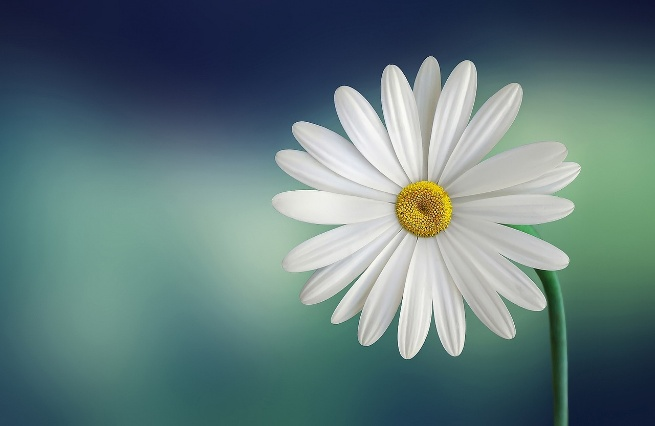
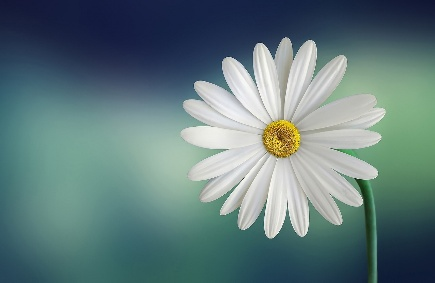
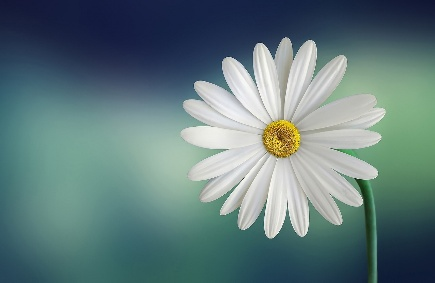
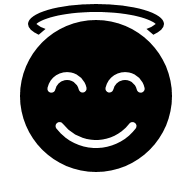
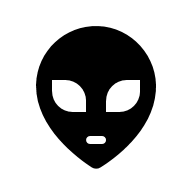

In [14]:
from IPython.core.display import HTML

def show_html(html: str) -> None:
	display(HTML(f"""
		<iframe srcdoc='{html}' width="100%" height="750px" style="border:none;"></iframe>
	"""))

show_html(html)

In [15]:
from random import randrange
from document_processor import render_review_html, DocumentInput, TextAnnotation

para_list = [para for para in doc.paragraphs]
run_list = [run for para in para_list for run in para.runs]

def get_rand_elem(ls: list):
    res = ls[randrange(len(ls))]
    while not res.text.strip():
        res = ls[randrange(len(ls))]
    return res

rand1 = get_rand_elem(run_list)
rand2 = get_rand_elem(run_list)
rand3 = get_rand_elem(para_list)

# cell만 다루기 - 예시용 셀
rand4 = [
    cell
    for para in doc.paragraphs
    for table in para.tables
    for row in table.cells
    for cell in row
][1]

doc_input = DocumentInput(doc_ir=doc)


In [16]:
annotated_result = render_review_html(
	document=doc_input,
	annotations=[
		TextAnnotation(
			target_kind="run",  # AnnotationTargetKind = Literal["paragraph", "run"]
            target_id=rand1.node_id,
            selected_text=rand1.text,
            occurrence_index=0,
            label="match",
            color="#727cff"
		),
		TextAnnotation(
			target_kind="run",
			target_id=rand2.node_id,
			selected_text=rand2.text,
			occurrence_index=0,
			label="match",
			color="#ff6e6e"
		),
		TextAnnotation(
			target_kind="paragraph",
			target_id=rand3.node_id,
			selected_text=rand3.text,
			occurrence_index=0,
			label="하늘샛 하이라이팅!",
			color="#6effd8"
		)
	]
)

f'result validation ok?: {annotated_result.ok}', \
    (rand1.node_id, rand1.text), (rand2.node_id, rand2.text), (rand3.node_id, rand3.text)

('result validation ok?: True',
 ('r_6c9a71e42264dc46', '※ '),
 ('r_3f1ff7241702452b', ' ('),
 ('p_380380582a7cf328', 'Lowest level none'))


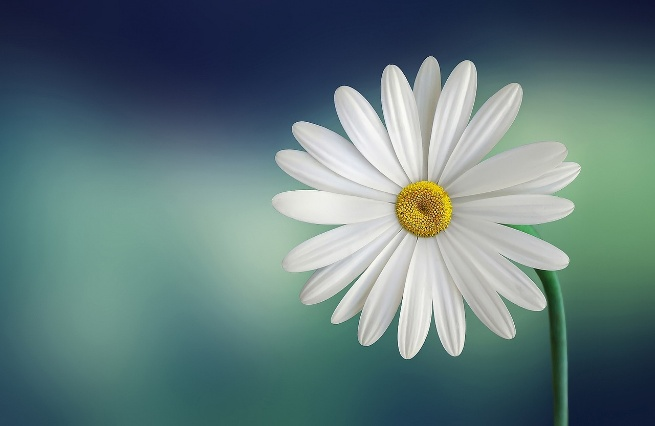
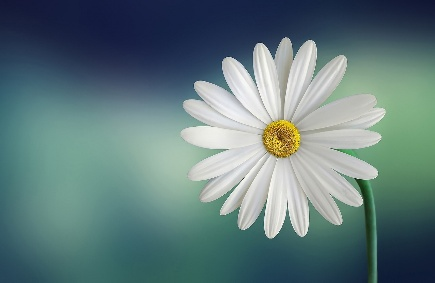
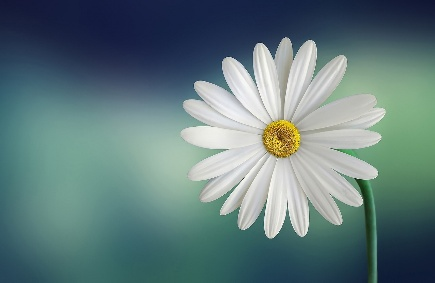
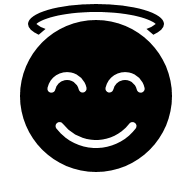
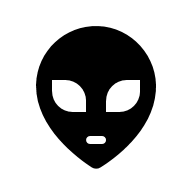

In [17]:
show_html(annotated_result.html)

## 문서 수정하기

In [18]:
from document_processor import apply_document_edits, TextEdit

assert rand4.node_id  # 린터 경고 없에기

edited_result = apply_document_edits(
	document=doc_input,
	edits=[
		TextEdit(
            target_id=rand1.node_id,
            expected_text_hash=rand1.native_anchor.text_hash,
            new_text="Hello Legal World",
            reason="Expand wording",
        ),
		TextEdit(
            target_id=rand3.node_id,
            expected_text_hash=rand3.native_anchor.text_hash,
            new_text="Hello Legal World",
            reason="Expand wording",
        ),
		TextEdit(
            target_id=rand4.node_id,
            expected_text_hash=rand4.native_anchor.text_hash,
            new_text="Hello Legal World",
            reason="Expand wording",
        ),
	],
 	return_doc_ir=True
)

f'result validation ok?: {edited_result.ok}', \
    (rand1.node_id, rand1.text), (rand3.node_id, rand3.text), (rand4.node_id, rand4.text)

('result validation ok?: True',
 ('r_6c9a71e42264dc46', '※ '),
 ('p_380380582a7cf328', 'Lowest level none'),
 ('cell_0aea70a2793f0544', '홍길동'))

위처럼 `edited_result.ok`가 False인 경우 exception 처리가 안나오게 설계됨, `.validation.issues`통해서 오류 확인 가능. -> langrgaph/langchain/pydanticAI 처리위함

(파일에 따라 위 예시에서 오류 안나올수도)

In [19]:
edited_result.validation.issues

[]

수정 결과 객체 구조:

In [20]:
from document_processor import ApplyDocumentEditsResult
ApplyDocumentEditsResult.model_fields

{'ok': FieldInfo(annotation=bool, required=False, default=True),
 'source_doc_type': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'source_name': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'output_path': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'output_filename': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'output_bytes': FieldInfo(annotation=Union[bytes, NoneType], required=False, default=None),
 'updated_doc_ir': FieldInfo(annotation=Union[DocIR, NoneType], required=False, default=None),
 'edits_applied': FieldInfo(annotation=int, required=False, default=0),
 'operations_applied': FieldInfo(annotation=int, required=False, default=0),
 'styles_applied': FieldInfo(annotation=int, required=False, default=0),
 'modified_target_ids': FieldInfo(annotation=list[str], required=False, default_factory=list),
 'created_target_ids': FieldInfo(annotation=list[str], require

In [21]:
from document_processor import EditValidationIssue
EditValidationIssue.model_fields

{'code': FieldInfo(annotation=Literal['target_not_found', 'target_kind_mismatch', 'text_hash_mismatch', 'mixed_content_not_supported', 'paragraph_count_mismatch', 'invalid_operation', 'invalid_position', 'invalid_table_shape', 'index_out_of_bounds', 'unsupported_source_doc_type', 'output_path_conflicts_with_source', 'native_source_required', 'invalid_style'], required=True),
 'target_kind': FieldInfo(annotation=Union[Literal['paragraph', 'run', 'cell', 'table', 'image'], NoneType], required=False, default=None),
 'target_id': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'operation': FieldInfo(annotation=Union[Literal['insert_paragraph', 'remove_paragraph', 'insert_run', 'remove_run', 'insert_table', 'remove_table', 'set_cell_text', 'insert_table_row', 'remove_table_row', 'insert_table_column', 'remove_table_column'], NoneType], required=False, default=None),
 'message': FieldInfo(annotation=str, required=True),
 'expected_text_hash': FieldInfo(annotation=U

오류문구:
```
Cell text replacement for cell_c140d37cf7f53629 must preserve paragraph count: expected 2 line(s), got 1.
```
> `\n` 통해 paragraph break인식 시키도록 하면 됨

In [22]:
edits1 = [
	TextEdit(
		target_id=rand1.node_id,
		expected_text_hash=rand1.native_anchor.text_hash,
		new_text=" Hello Legal World ",
		reason="Expand wording",
	),
	TextEdit(
		target_id=rand3.node_id,
		expected_text_hash=rand3.native_anchor.text_hash,
		new_text="\n[Paragraph replaced here!]\n",
		reason="Expand wording",
	),
	TextEdit(
		target_id=rand4.node_id,
		expected_text_hash=rand4.native_anchor.text_hash,
		new_text="Hello! Legal World",  # \n 통해서 paragraph 분리
		reason="Expand wording",
	),
]

edited_result = apply_document_edits(
	document=doc_input,
	edits=edits1,
 	return_doc_ir=True
)

f'result validation ok?: {edited_result.ok} | {edited_result.validation.issues}', \
    (rand1.node_id, rand1.text), (rand3.node_id, rand3.text), (rand4.node_id, rand4.text)

('result validation ok?: True | []',
 ('r_6c9a71e42264dc46', '※ '),
 ('p_380380582a7cf328', 'Lowest level none'),
 ('cell_0aea70a2793f0544', '홍길동'))


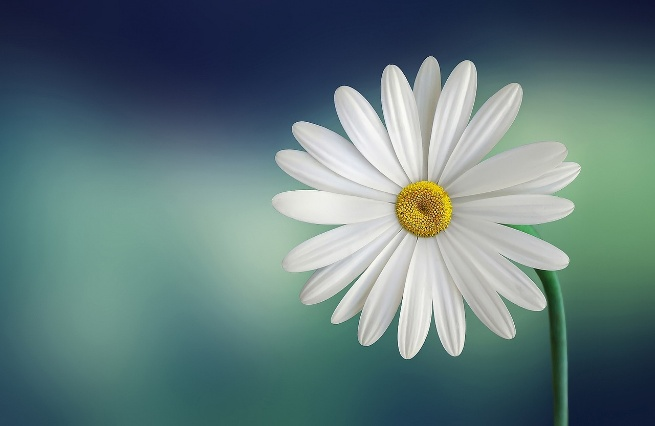
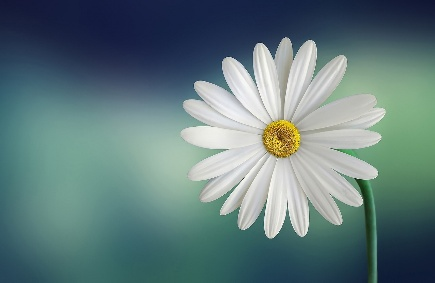
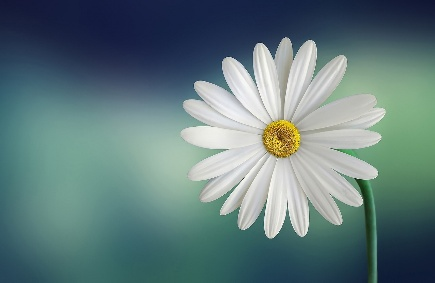
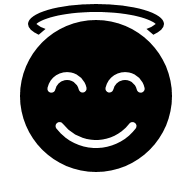
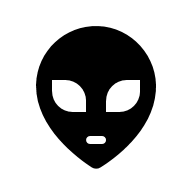

In [23]:
show_html(edited_result.updated_doc_ir.to_html())

stateless API이므로 수정된거로 input 객체 변경

In [24]:
doc_input  = DocumentInput(doc_ir=edited_result.updated_doc_ir)

In [25]:
from document_processor import StructuralEdit
assert rand4.node_id  # 린터 경고 없에기

'''
operation 종류들
Literal[
    "insert_paragraph",
    "remove_paragraph",
    "insert_run",
    "remove_run",
    "insert_table",
    "remove_table",
    "set_cell_text",
    "insert_table_row",
    "remove_table_row",
    "insert_table_column",
    "remove_table_column",
]
'''

struct_edit_result = apply_document_edits(
	document=doc_input,
	edits=[
		StructuralEdit(
			operation="insert_paragraph",
			target_id=rand3.node_id,
			position="before",
			text="paragraph 추가된거임!!!!!"
		),
		StructuralEdit(
			operation="insert_paragraph",
			target_id=rand3.node_id,
			position="after",
			text="paragraph 추가된거임!!!!!"
		),
		StructuralEdit(
			operation="insert_table_row",
			target_id=rand4.node_id,  # cell id 기준으로 행 작업 수행함
			position="after",
			values=['행 추가된겨', '행 추가된겨']
		),
		StructuralEdit(
			operation="insert_table_column",
			target_id=rand4.node_id,  # cell id 기준으로 렬 작업 수행함
			position="after",
			values=['1', '2', '3', '4', '5', '6']
		),
	],
 	return_doc_ir=True
)

f'result validation ok?: {struct_edit_result.ok}', \
    (rand3.node_id, rand1.text), (rand3.node_id, rand3.text), (rand4.node_id)

('result validation ok?: True',
 ('p_380380582a7cf328', '※ '),
 ('p_380380582a7cf328', 'Lowest level none'),
 'cell_0aea70a2793f0544')

In [26]:
struct_edit_result.validation.issues, struct_edit_result.created_target_ids

([],
 ['p_9be5db3c2899c400',
  'r_ca178a8d0e3cd466',
  'p_111b200fe6a680a5',
  'r_c426e824d0434689',
  'cell_7e4cedd9b8ff998c',
  'p_e027b82cd1c3ffb3',
  'r_d3d3370184536f5c',
  'cell_d5fd43255b9caa92',
  'p_d634008d49c8a10d',
  'r_16435cc8a185720d',
  'cell_6afe614e614b43c0',
  'p_1cc697fa50b80456',
  'r_3f67c1345afcaea9',
  'cell_8549822ba510ed37',
  'p_dfff5866e36f02a9',
  'r_2f0d6d93a5a0f541',
  'cell_be32c01e888967a7',
  'p_dfd20ddc8d535257',
  'r_af65f64dc48d3874',
  'cell_98a87ec92a0a57c7',
  'p_d17626187aac3987',
  'r_941a5c05390a154b',
  'cell_08a84558ae4ae128',
  'p_06268801f3e67424',
  'r_102c92136044567f',
  'cell_6c393533ca0eae16',
  'p_d0d18ace89a76e32',
  'r_1c1e16c8bbe0a75d'])

**연달아 추가된 작업의 경우에는 순차적으로 진행**


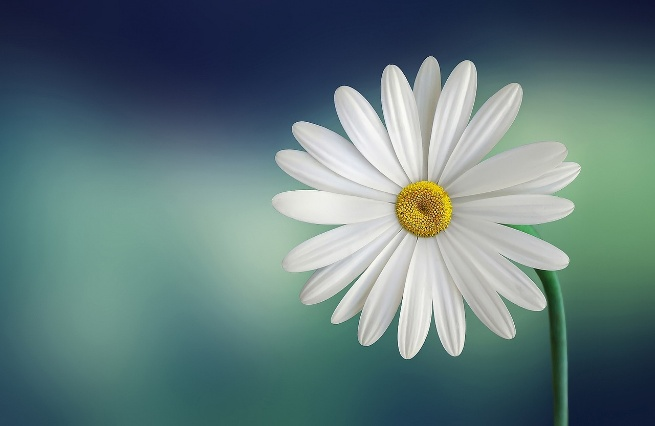
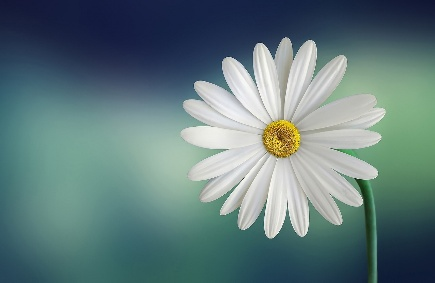
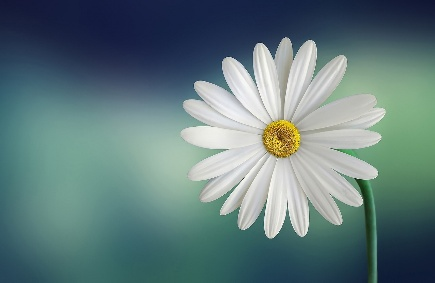
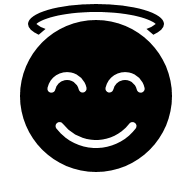
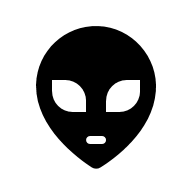

In [27]:
show_html(struct_edit_result.updated_doc_ir.to_html())

In [28]:
tables = [table for para in doc.paragraphs for table in para.tables]
tables

[TableIR(meta=None, node_id='tbl_9034239195ff7a13', previous_table_id=None, next_table_id=None, row_count=5, col_count=2, bbox=None, table_style=TableStyleInfo(row_count=5, col_count=2, width_pt=491.25, height_pt=170.8, placement=None, render_grid=False), cells=[[TableCellIR(meta=None, node_id='cell_8a01d786c0a73f25', text='성명', bbox=None, cell_style=CellStyleInfo(background='#D6E4F0', vertical_align='center', horizontal_align=None, width_pt=117.75, height_pt=23.05, padding_top_pt=0.0, padding_right_pt=5.4, padding_bottom_pt=0.0, padding_left_pt=5.4, border_top='1px solid #000000', border_bottom='1px solid #000000', border_left='1px solid #000000', border_right='1px solid #000000', diagonal_tl_br=None, diagonal_tr_bl=None, rowspan=1, colspan=1), paragraphs=[ParagraphIR(meta=None, node_id='p_04d51c49fdadfdb1', text='성명', page_number=1, bbox=None, para_style=ParaStyleInfo(align='center', left_indent_pt=None, right_indent_pt=None, first_line_indent_pt=None, hanging_indent_pt=None, render_

In [29]:
[print('\t\t'.join([cell.text for cell in row])) for table in tables for row in table.cells]
print()

성명		홍길동
생년월일		1990.01.15
근무지		서울특별시 강남구
업무내용		소프트웨어 개발
계약기간		2025.01.01 ~ 2025.12.31
구분
지급일
기본급
매월 25일 
수당
성과급  & 분기별

구분		지급일		금액
기본급		매월 25일		2,500,000원
수당		매월 25일		300,000원
성과급		분기별		200,000원
라마바사				
		가나다		12345
				



## 복합 작업 + 스타일 수정

In [30]:
from document_processor import StyleEdit, list_editable_targets
assert rand4.node_id  # 린터 경고 없에기

targets = list_editable_targets(
	document=doc_input,
	target_ids=[rand3.node_id]
)
new_hash = targets.targets[0].text_hash
new_hash

'c98d47f4bed14c1cc31e80a8f36e57d6405e72d8'

In [31]:
edits2 = [
	StructuralEdit(
		operation="insert_paragraph",
		target_id=rand3.node_id,
		position="before",
		text="paragraph 추가된거임!!!!!"
	),
	StructuralEdit(
		operation="insert_paragraph",
		target_id=rand3.node_id,
		position="after",
		text="paragraph 추가된거임!!!!!"
	),
	StructuralEdit(
		operation="insert_table_row",
		target_id=rand4.node_id,  # cell id 기준으로 행 작업 수행함
		position="after",
		values=['행 추가된겨', '행 추가된겨']
	),
	TextEdit(
		target_id=rand3.node_id,
		expected_text_hash=new_hash,
		new_text="이제 여기 색갈도 바뀜",
		reason="Expand wording",
	),
	StructuralEdit(
		operation="insert_table_column",
		target_id=rand4.node_id,  # cell id 기준으로 열 작업 수행함
		position="after",
		values=['1','2','3','4','5','6']
	),
	StyleEdit(
		target_id=rand3.runs[0].node_id,
		bold=True,
		color="#4C3EB8",
		font_size_pt=32,
	),
	*[  # list unpacking 통해서 안에 여러개 동시 주입 가능!!
		StyleEdit(
			target_id=run.node_id,
			color="#FFFFFF",
		)
		for para in rand4.paragraphs for run in para.runs
	],
	*[
		StyleEdit(
			target_id=para.node_id,
			paragraph_align="right"  # 여기 주목! ↓
		)
		for para in rand4.paragraphs
	],
	StyleEdit(
		target_id=rand4.node_id,
		background="#600B4F",
		padding_left_pt=10,
		padding_right_pt=10,
		height_pt=100,
		width_pt=200,
		horizontal_align="left",    # 여기 주목! ↑
		vertical_align="bottom",
		border_top="5pt single #000000",
		border_right="5pt single #000000",
		border_bottom="5pt single #000000",
		border_left="5pt single #000000",
	),
]

total_edit_result = apply_document_edits(
	document=doc_input,
	edits=edits2,
	return_doc_ir=True,
)

f'result validation ok?: {total_edit_result.ok}', \
    rand4.node_id, total_edit_result.validation.issues

('result validation ok?: True', 'cell_0aea70a2793f0544', [])

~~렌더링 우선순위 때문에 cell "horizontal_align" vs paragraph "paragraph_align" 둘이 뜨면 paragraph 렌더링이 우선순위를 가지게 됨, 다음 예시에서도 paragraph상에서 오른정렬한게 셀 단위 왼정렬한걸 이김~~


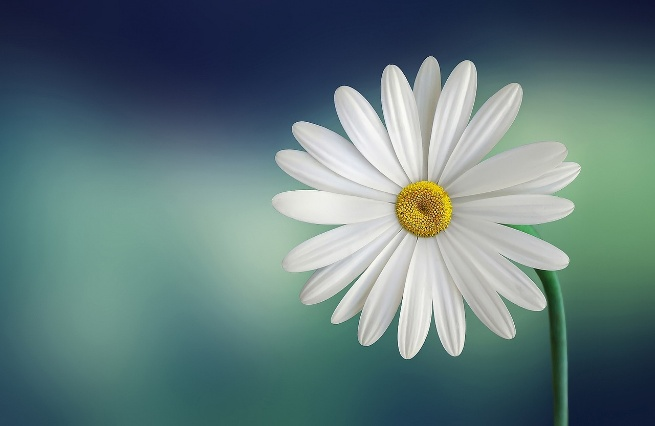
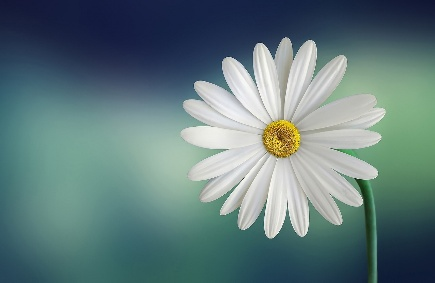
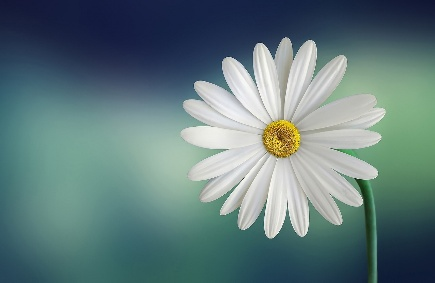
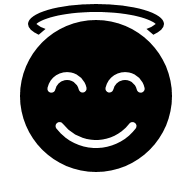
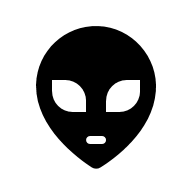

In [32]:
show_html(total_edit_result.updated_doc_ir.to_html(debug_layout=0))

In [33]:
total_edit_result.validation.issues

[]

**위 edits를 파일에 저장**

In [34]:
total_edit_result = apply_document_edits(
	document=DocumentInput(source_path=FP._str),
	edits=edits1 + edits2,
	return_doc_ir=True,
	output_filename='demo_result.hwpx'
)

print(f'result validation ok?: {total_edit_result.ok} | {total_edit_result.validation.issues}')

result validation ok?: False | [EditValidationIssue(code='invalid_operation', target_kind=None, target_id=None, operation=None, message="output_filename extension '.hwpx' does not match DOCX write-back; use '.docx'.", expected_text_hash=None, current_text_hash=None, current_text=None)]
